# pyerviss quickstart

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ngozzi/pyerviss/blob/main/notebooks/quickstart.ipynb)

Weekly ILI, ARI and SARI rates and influenza, RSV and SARS-CoV-2 test positivity for EU/EEA
countries, from ECDC's [ERVISS](https://erviss.org) data. This notebook shows how to load the
data and plot it.

> pyerviss is an independent, unofficial project, not affiliated with or endorsed by ECDC.
> Full documentation: https://pyerviss.readthedocs.io

## Install

On Colab, this installs pyerviss with plotting support. Locally, run
`pip install "pyerviss[plot]"` once instead.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install --quiet "pyerviss[plot]"

In [2]:
import pyerviss as pv

pv.__version__

'0.1.1'

## What is available

The first call downloads the data (a few MB) and caches it; later calls are fast.
`coverage` shows, for each country, which weeks and age groups have data.

In [3]:
pv.coverage("ili").head(8)

,country,country_code,first_week,last_week,n_weeks,age_groups,unit
0,Austria,AT,2014-W40,2026-W14,315,"[0-4, 5-14, 15-64, 65+, total]","per 100,000 population"
1,Belgium,BE,2014-W40,2026-W39,626,"[0-4, 5-14, 15-64, 65+, total]","per 100,000 population"
2,Croatia,HR,2014-W40,2026-W39,426,"[0-4, 5-14, 15-64, 65+, total]","per 100,000 population"
3,Cyprus,CY,2014-W40,2019-W25,242,[total],"per 100,000 consultations"
4,Czechia,CZ,2014-W40,2026-W36,607,"[0-4, 5-14, 15-64, 65+, total]","per 100,000 population"
5,Denmark,DK,2014-W40,2026-W39,508,"[0-4, 5-14, 15-64, 65+, total]","per 100,000 population"
6,Estonia,EE,2014-W40,2026-W38,614,"[0-4, 5-14, 15-64, 65+, total]","per 100,000 population"
7,Finland,FI,2015-W18,2026-W32,488,"[0-4, 5-14, 15-64, 65+, total]","per 100,000 consultations"


In [4]:
print("Latest week with data:", pv.latest_week())
print("Countries with SARI data:", ", ".join(pv.list_countries("sari")))

Latest week with data: 2026-W39
Countries with SARI data: Austria, Belgium, Croatia, Cyprus, Estonia, Germany, Greece, Iceland, Ireland, Latvia, Lithuania, Luxembourg, Malta, Romania, Slovakia, Spain


## Loading data

Every query returns a long-format DataFrame: one row per country, week and age group. Filter
by country (names or ISO2 codes), weeks, dates or seasons (a season such as `"2024/25"` runs
from 2024-W40 to 2025-W39), and age group.

In [5]:
ili = pv.get_ili(countries="Italy", age_groups="total")
ili.tail()

,indicator,country,country_code,year_week,date,age,value,unit
303,ili,Italy,IT,2025-W13,2025-03-30,total,692.5,"per 100,000 population"
304,ili,Italy,IT,2025-W14,2025-04-06,total,611.3,"per 100,000 population"
305,ili,Italy,IT,2025-W15,2025-04-13,total,573.9,"per 100,000 population"
306,ili,Italy,IT,2025-W16,2025-04-20,total,482.2,"per 100,000 population"
307,ili,Italy,IT,2025-W17,2025-04-27,total,368.2,"per 100,000 population"


The `unit` column says what `value` measures. It differs by country: for example Malta
reports per consultations rather than per population, so rates are not always comparable.
See [Units](https://pyerviss.readthedocs.io/en/latest/units.html).

In [6]:
df = pv.get_ili(countries=["Italy", "MT"], season="2024/25", age_groups="total")
df.groupby("country")["unit"].first()

country
Italy       per 100,000 population
Malta    per 100,000 consultations
Name: unit, dtype: str

## Plotting seasons

`plot_seasons` draws one line per season, aligned on the week of the season. Past seasons are
grey; the most recent one is highlighted.

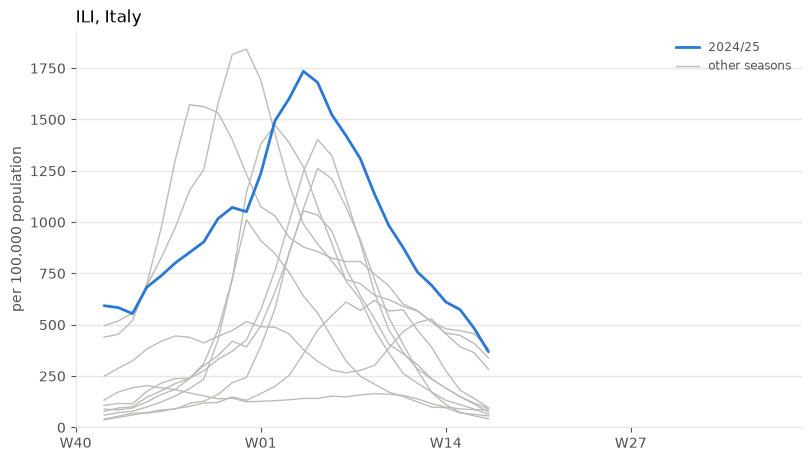

In [7]:
pv.plot_seasons(ili);

### Comparing countries

`facet="country"` draws one panel per country, with the same season highlighted in each. Each
panel has its own y-axis because levels and units differ.

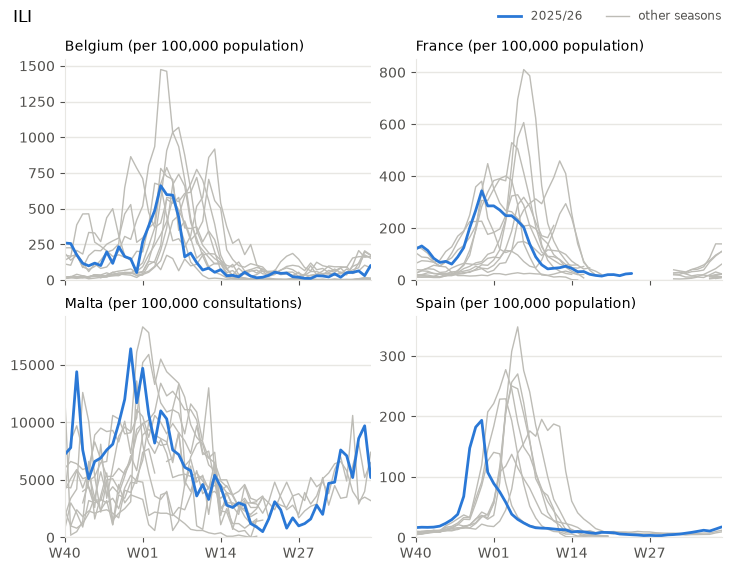

In [8]:
countries = ["Belgium", "France", "Spain", "Malta"]
pv.plot_seasons(pv.get_ili(countries=countries, age_groups="total"), facet="country");

### Comparing age groups

`facet="age"` draws one panel per age group. Age-specific data starts in 2022, so those
panels show fewer past seasons.

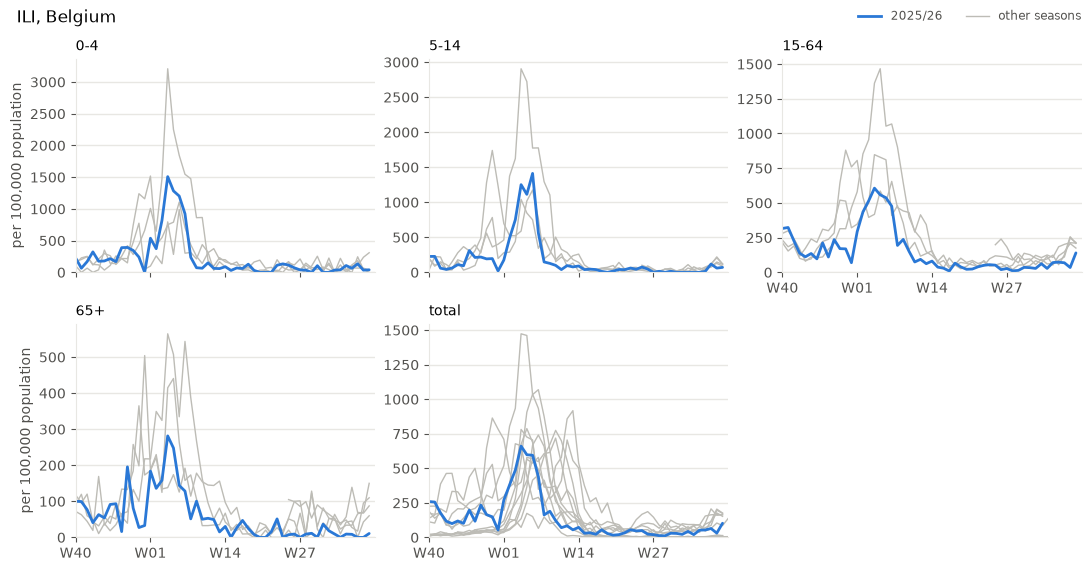

In [9]:
pv.plot_seasons(pv.get_ili(countries="Belgium"), facet="age");

## Positivity

`get_positivity` returns the percentage of tested samples that were positive, with the
`tests` and `detections` counts behind it. Many weeks rest on few tests, so the counts
matter.

In [10]:
pos = pv.get_positivity(pathogen="influenza", setting="primary care", countries="IT")
pos[["year_week", "value", "unit", "tests", "detections"]].tail()

,year_week,value,unit,tests,detections
88,2026-W05,17.9,%,786,141
89,2026-W06,8.9,%,652,58
90,2026-W07,7.6,%,594,45
91,2026-W08,4.9,%,512,25
92,2026-W09,1.5,%,460,7


`add_positivity_ci` adds a 95% confidence interval computed from those counts, which
`plot_seasons` draws as a band. Wide bands mean few tests.

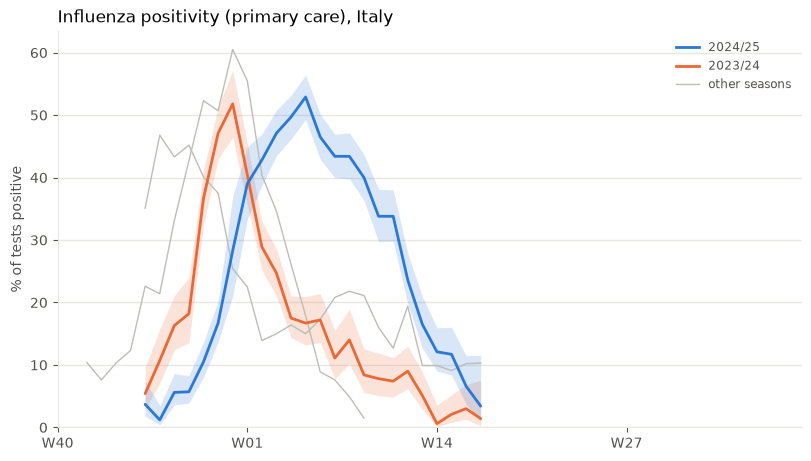

In [11]:
pv.plot_seasons(pv.add_positivity_ci(pos), highlight=["2023/24", "2024/25"]);

## Working with the data

Results are ordinary pandas DataFrames: pivot, aggregate or export them as usual.

In [12]:
df = pv.get_ili(countries=["Belgium", "Spain"], season="2024/25", age_groups="total")
wide = df.pivot(index="date", columns="country", values="value")
wide.head()

country,Belgium,Spain
date,,
2024-10-06,225.8,10.2
2024-10-13,226.4,9.8
2024-10-20,185.6,10.6
2024-10-27,120.7,10.5
2024-11-03,59.4,9.0


In [13]:
# Save to CSV
wide.to_csv("ili_2024_25.csv")

## Next steps

- [Querying data](https://pyerviss.readthedocs.io/en/latest/querying.html): all filters
- [Positivity](https://pyerviss.readthedocs.io/en/latest/positivity.html)
- [Plotting](https://pyerviss.readthedocs.io/en/latest/plotting.html)
- [Units](https://pyerviss.readthedocs.io/en/latest/units.html): read before comparing
  countries